## 1. 📦 Import & Config

In [ ]:
import torch
import numpy as np
import json
import os
import matplotlib.pyplot as plt

from sklearn.metrics import r2_score
from pathlib import Path
from tqdm.auto import tqdm
from scipy.stats import wasserstein_distance

from utils import setup_logging, setup_random_seed, load_processed_store, simulate_mc_gbm,  plot_compare_dist, plot_compare_correlation, plot_compare_rolling_vol, _kl_divergence
from utils.paths import EXPERIMENTS_DIR, PROCESSED_DIR
from config import Config
from models import Diffusion, DiffusionTransformer

logger = setup_logging()

2026-04-02 02:33:48,552 - utils.setup - INFO - Logger is set up.


In [ ]:
config = Config(
    device = "cuda:0",
    processed_name="trial20_w30h252a14rand78"
)
config.inference.n_paths = 10
setup_random_seed(config.random_seed)

device = torch.device(config.device)
print(f"Device: {device}")

EXP_NAME    = "20260401_220400_trial20_w30h252a14rand78_optuna"
CKPT_FILE   = "best_trial20_w30h252a14rand78.pt"
SIM_NAME = "trial20_n1000"

exp_dir     = Path(EXPERIMENTS_DIR) / EXP_NAME
ckpt_path   = exp_dir / "checkpoints" / CKPT_FILE
sim_dir  = Path(EXPERIMENTS_DIR) / "simulations" / SIM_NAME
sim_dir.mkdir(parents=True, exist_ok=True)

with open(exp_dir / "optuna" / "best_params.json") as f:
    best_params = json.load(f)

print("Best params:", json.dumps(best_params, indent=2))

num_layers          = best_params["n_layers"]
num_attention_heads = best_params["n_heads"]
d_model             = best_params["d_model"]
dim_feedforward     = best_params["dim_feedforward"]
dropout             = best_params["dropout"]
timesteps           = best_params["timesteps"]
beta_start          = best_params["beta_start"]
beta_end            = best_params["beta_end"]

print(f"Experiment : {exp_dir}")
print(f"Checkpoint : {ckpt_path}")
print(f"Sim output : {sim_dir}")

Device: cuda:0
Best params: {
  "d_model": 1024,
  "n_heads": 16,
  "n_layers": 3,
  "dim_feedforward": 4096,
  "dropout": 0.2,
  "timesteps": 2000,
  "lr": 0.00032558417175832216,
  "weight_decay": 2.7245528116114333e-07,
  "beta_start": 4.388380095845899e-05,
  "beta_end": 0.047854256478792406
}
Experiment : /home/narodom.y@FUSION.LAB/research/experiments/20260401_220400_trial20_w30h252a14rand78_optuna
Checkpoint : /home/narodom.y@FUSION.LAB/research/experiments/20260401_220400_trial20_w30h252a14rand78_optuna/checkpoints/best_trial20_w30h252a14rand78.pt
Sim output : /home/narodom.y@FUSION.LAB/research/experiments/simulations/trial20_n1000


## 2 · Load Feature Store

In [ ]:
parts, datasets, loaders, meta = load_processed_store(
    store_name   = config.processed_name,
    saved_dir    = Path(PROCESSED_DIR),
    batch_size   = config.train.batch_size,
    batch_size_test = config.train.batch_size_test,
    shuffle_train= False,
)


test_loader = loaders["test"]

# Shape info from first batch
sample = next(iter(test_loader))
B, A, T, C      = sample["x"].shape
C_cond          = sample["cond"].shape[-1]

print(f"x    shape : {sample['x'].shape}   → [B, A, T, C]")
print(f"cond shape : {sample['cond'].shape} → [B, A, T, C_cond]")
print(f"Assets     : {A}  |  Window : {T}  |  Channels : {C}  |  Cond channels : {C_cond}")

✅ Loaded feature store  →  /home/narodom.y@FUSION.LAB/research/experiments/features/trial20_w30h252a14rand78
   train: 1477 windows
   val  : 158 windows
   test : 5 windows
x    shape : torch.Size([1, 14, 30, 253])   → [B, A, T, C]
cond shape : torch.Size([1, 14, 30, 8]) → [B, A, T, C_cond]
Assets     : 14  |  Window : 30  |  Channels : 253  |  Cond channels : 8


## 3. Build Model & Load Checkpoint

In [ ]:
backbone = DiffusionTransformer(
    num_assets         = A,
    num_channels       = C,
    num_cond_channels  = C_cond,
    num_layers         = num_layers,
    num_attention_heads= num_attention_heads,
    seq_length         = T,
    d_model            = d_model,
    dim_feedforward    = dim_feedforward,
    dropout            = dropout,
).to(device)

model = Diffusion(
    model      = backbone,
    timesteps  = timesteps,
    beta_start = beta_start,
    beta_end   = beta_end,
).to(device)

# Load checkpoint
ckpt = torch.load(ckpt_path, map_location=device)
model.load_state_dict(ckpt["model_state_dict"])
model.eval()

total_params = sum(p.numel() for p in model.parameters())
print(f"Model loaded ✅  ({total_params:,} params)")

input dim x: 3542, d_model: 1024


/tmp/ipykernel_222856/482449056.py:21: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(ckpt_path, map_location=device)


Model loaded ✅  (59,894,230 params)


## 4. Run Inference

In [ ]:
print(f"test windows : {len(datasets['test'])}")
print(f"batch_size   : {test_loader.batch_size}")
print(f"n_batches    : {len(test_loader)}")

test windows : 5
batch_size   : 1
n_batches    : 5


In [ ]:
all_generated    = []
all_actual       = []
all_dates        = []
all_close_prices = []
all_x_prev_mean       = []
all_x_prev_std        = []
all_x_prev = []

with torch.no_grad():
    for batch in tqdm(test_loader, desc="Inference"):
        x    = batch["x"].to(device)     # [1, A, T, C]
        cond = batch["cond"].to(device)  # [1, A, T, C_cond]

        x_rep    = x.expand(config.inference.n_paths, -1, -1, -1)
        cond_rep = cond.expand(config.inference.n_paths, -1, -1, -1)

        x_gen = model.sample(x_cond=cond_rep, output_shape=x_rep.shape)  # [n_paths, A, T, C]

        all_generated.append(x_gen.cpu().numpy())
        all_actual.append(x.squeeze(0).cpu().numpy())           # [A, T, C]
        all_dates.append(batch["dates"].squeeze(0).numpy())     # [T]
        all_close_prices.append(batch["close_prices"].squeeze(0).numpy())
        all_x_prev_mean.append(batch["x_prev_mean"].squeeze(0).numpy())
        all_x_prev_std.append(batch["x_prev_std"].squeeze(0).numpy())
        all_x_prev.append(batch["x_prev"].squeeze(0).numpy())
# Stack
generated    = np.stack(all_generated)     # [N_windows, n_paths, A, T, C]
actual       = np.stack(all_actual)        # [N_windows, A, T, C]
dates        = np.stack(all_dates)         # [N_windows, T]
close_prices = np.stack(all_close_prices)  # [N_windows, A, T]
x_prev_mean  = np.stack(all_x_prev_mean)   # [N_windows, A, F]
x_prev_std   = np.stack(all_x_prev_std)    # [N_windows, A, F]
x_prev       = np.stack(all_x_prev)        # [N_windows, A, T, C]

print(f"Generated    : {generated.shape}")
print(f"Actual       : {actual.shape}")
print(f"Dates        : {dates.shape}")
print(f"Close prices : {close_prices.shape}")
print(f"X prev mean  : {x_prev_mean.shape}")
print(f"X prev std   : {x_prev_std.shape}")
print(f"X prev       : {x_prev.shape}")

Inference:   0%|          | 0/5 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
# save_path = sim_dir / "sim_results.npz"

# np.savez_compressed(
#     save_path,
#     generated    = generated,
#     actual       = actual,
#     dates        = dates,
#     close_prices = close_prices,
#     x_prev_mean       = x_prev_mean,
#     x_prev_std        = x_prev_std,
#     x_prev       = x_prev,
# )

# sim_meta = {
#     "exp_name"       : EXP_NAME,
#     "checkpoint"     : CKPT_FILE,
#     "processed_name" : config.processed_name,
#     "n_windows"      : int(generated.shape[0]),
#     "n_paths"        : int(generated.shape[1]),
#     "n_assets"       : int(generated.shape[2]),
#     "window_size"    : int(generated.shape[3]),
#     "channels"       : int(generated.shape[4]),
#     "symbols"        : config.feature.symbols,
#     "device"         : str(device),
# }

# with open(sim_dir / "sim_meta.json", "w") as f:
#     json.dump(sim_meta, f, indent=4)

# print(f"Saved → {save_path}")
# print(json.dumps(sim_meta, indent=2))

## 5. MC GBM simulation 

In [ ]:
import pandas as pd
import numpy as np

flat_dates = dates.reshape(-1)  # [N*T]
dt_series  = pd.to_datetime(flat_dates)

print(f"Total steps : {len(dt_series)}")
print(f"First date  : {dt_series[0].date()}")
print(f"Last date   : {dt_series[-1].date()}")
print()

# เช็ค overlap — ถ้าไม่มีซ้ำ unique == total
n_unique = dt_series.nunique()
print(f"Unique dates : {n_unique}  /  Total : {len(dt_series)}")
print(f"Overlap      : {len(dt_series) - n_unique} days  {'✅ ไม่มี overlap' if n_unique == len(dt_series) else '⚠️ มี overlap!'}")
print()

# เช็ค gap — วันซื้อขายควรห่างกัน 1 วัน (weekday) ไม่ควรข้ามสัปดาห์แปลกๆ
gaps = dt_series.diff().dropna()
gap_counts = gaps.value_counts().head(5)
print("Top 5 gaps between consecutive dates:")
print(gap_counts.to_string())

Total steps : 150
First date  : 2022-05-16
Last date   : 2022-12-16

Unique dates : 150  /  Total : 150
Overlap      : 0 days  ✅ ไม่มี overlap

Top 5 gaps between consecutive dates:
1 days    118
3 days     26
4 days      4
2 days      1


In [ ]:
N, A, T, C = actual.shape
horizon    = N * T   # 150 วัน

# 1. actual cat → [A, horizon]
actual_cat = actual[:, :, :, 0]             # [N, A, T]  channel 0
actual_cat = actual_cat.transpose(0, 2, 1)  # [N, T, A]  -- ต้องการ T ต่อกัน
actual_cat = actual_cat.reshape(-1, A).T    # [A, horizon]

# 2. x_prev window แรกอย่างเดียว → [T, A]
lr_prev = x_prev[0, :, :, 0].T             # [A, T] → [T, A]
lr_prev_t = torch.tensor(lr_prev, dtype=torch.float32, device=device)

# 3. simulate GBM
gbm_paths = simulate_mc_gbm(
    log_returns = lr_prev_t,    # [T, A]
    n_paths     = config.inference.n_paths,
    horizon     = horizon,      # 150
)
# gbm_paths shape: [n_paths, horizon, A]
# transpose → [n_paths, A, horizon]  ให้ match genai
gbm_paths = gbm_paths.permute(0, 2, 1).cpu().numpy()

print(f"actual_cat : {actual_cat.shape}")   # [A, 150]
print(f"gbm_paths  : {gbm_paths.shape}")    # [n_paths, A, 150]

actual_cat : (14, 150)
gbm_paths  : (10, 14, 150)


## 6. Cat windows

In [ ]:
gen_cat = generated[:, :, :, :, 0]         # [N, n_paths, A, T]
gen_cat = gen_cat.transpose(1, 2, 0, 3)    # [n_paths, A, N, T]
gen_cat = gen_cat.reshape(
    config.inference.n_paths, A, horizon   # [n_paths, A, N*T]
)

print(f"gen_cat : {gen_cat.shape}")

gen_cat : (10, 14, 150)


In [ ]:
symbols = config.feature.symbols

# prep shape → [T, A]
actual_TA  = actual_cat.T                        # [A, 150] → [150, A]
genai_TA   = gen_cat.mean(axis=0).T              # [n_paths, A, 150] → [A, 150] → [150, A]
gbm_TA     = gbm_paths.mean(axis=0).T           # same

# GenAI vs Actual
# plot_compare_dist(actual_TA, genai_TA, symbols, title="GenAI vs Actual")
# plot_compare_correlation(actual_TA, genai_TA, symbols)
# plot_compare_rolling_vol(actual_TA, genai_TA, symbols)

# # GBM vs Actual
# plot_compare_dist(actual_TA, gbm_TA, symbols, title="GBM vs Actual")
# plot_compare_correlation(actual_TA, gbm_TA, symbols)
# plot_compare_rolling_vol(actual_TA, gbm_TA, symbols)

## 7. Sanity Check — Plot a few windows & Save Results

✅ npz saved  → /home/narodom.y@FUSION.LAB/research/experiments/simulations/trial19_n10/sim_results.npz
✅ mean path CSVs saved → /home/narodom.y@FUSION.LAB/research/experiments/simulations/trial19_n10/reports
✅ per-path CSVs saved → /home/narodom.y@FUSION.LAB/research/experiments/simulations/trial19_n10/reports
✅ metrics saved → /home/narodom.y@FUSION.LAB/research/experiments/simulations/trial19_n10/reports/metrics_comparison.csv
         MSE_GenAI  MAE_GenAI   KL_GenAI  Wasserstein_GenAI     R2_GenAI   MSE_GBM   MAE_GBM     KL_GBM  Wasserstein_GBM    R2_GBM
asset                                                                                                                             
AAPL   1135.595325  26.945275   3.798064          26.253026  -897.185359  1.261651  0.851227  20.485476         0.845247  0.002112
TSLA   1193.971200  26.580200  10.014103          25.800506  -676.959142  1.757890  0.843351  21.017669         0.837024  0.001837
MSFT    940.809172  24.441803   2.965616   

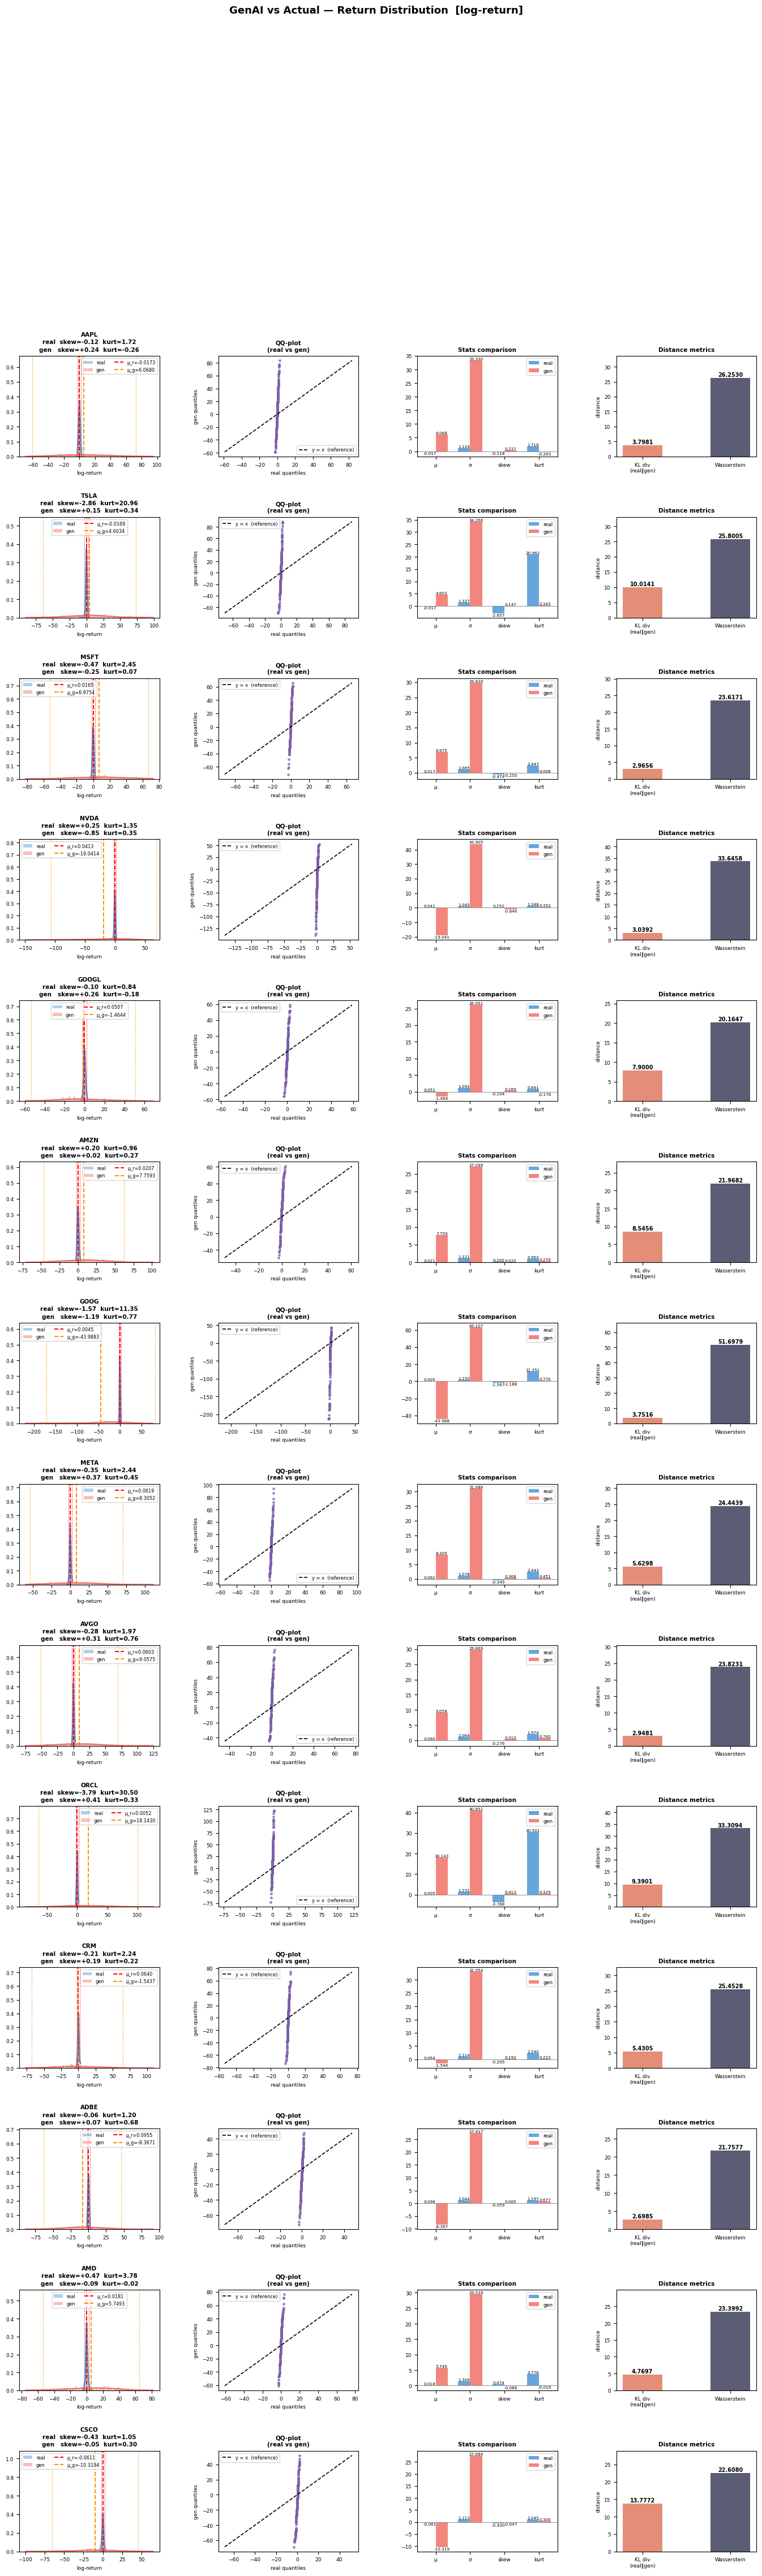

   dist_genai_vs_actual.png


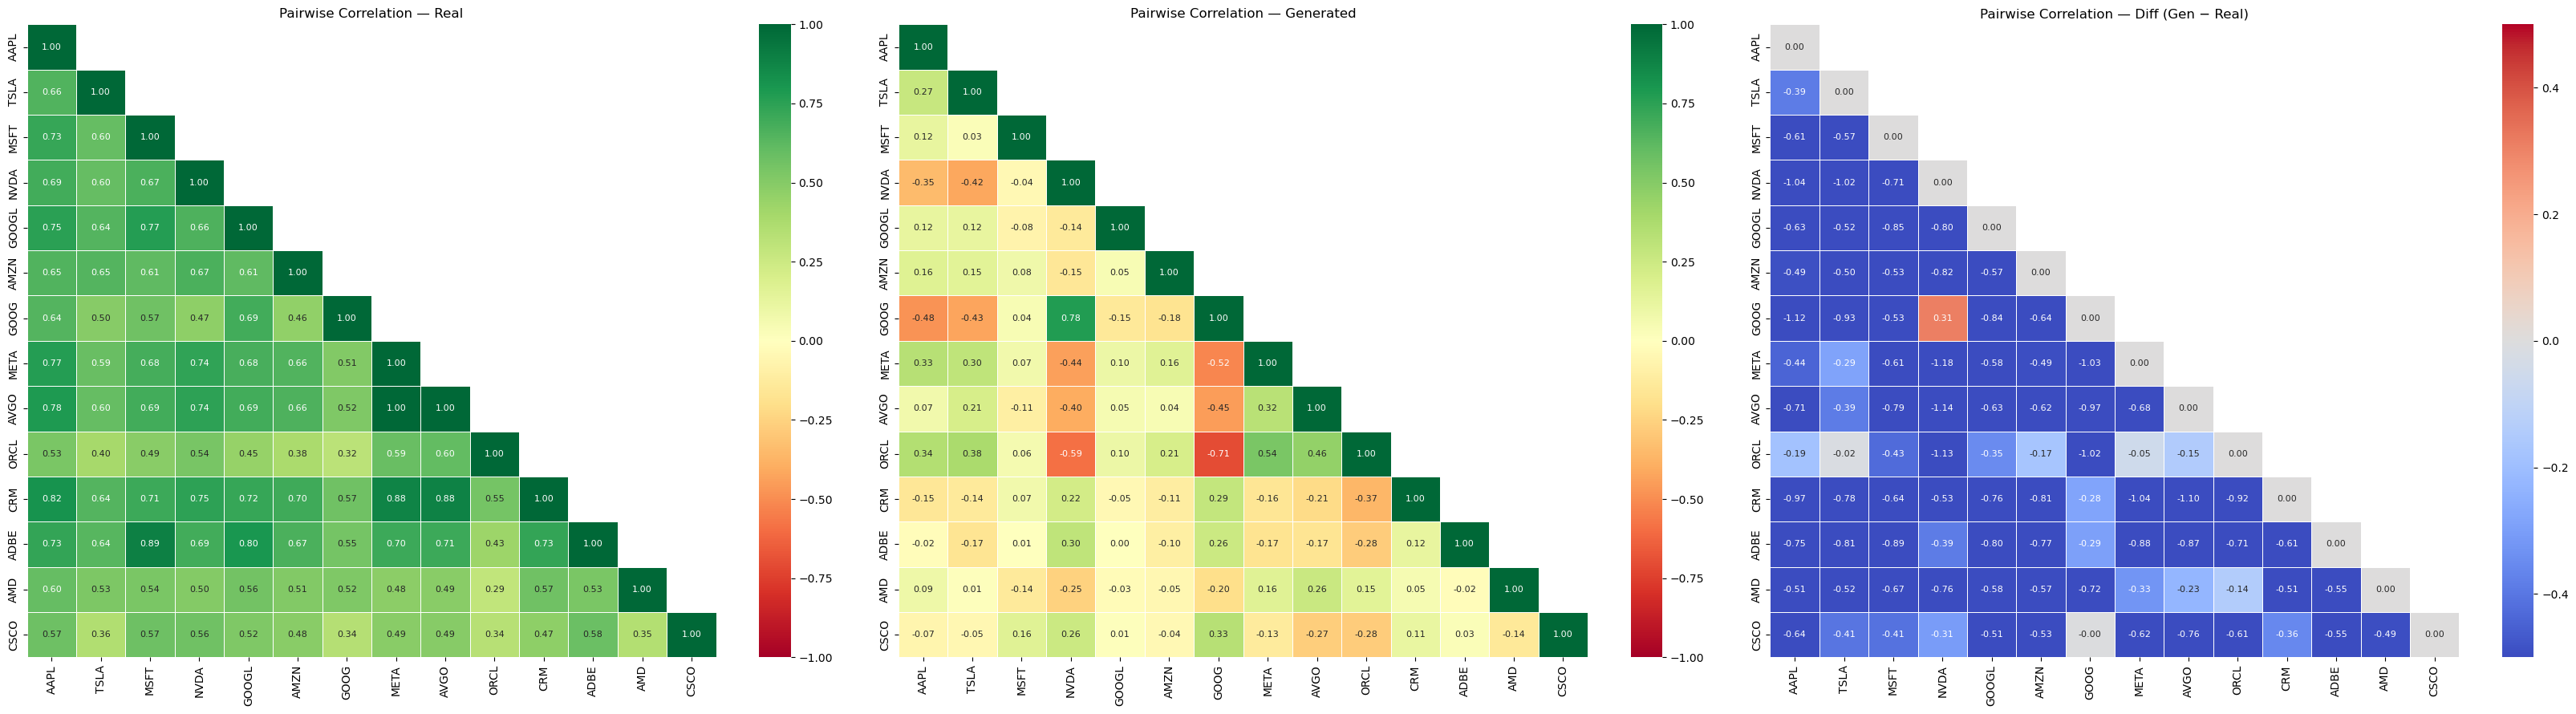


Pairs ที่ |r| > 0.85 ในอย่างน้อยหนึ่ง set:


,Asset A,Asset B,r_real,r_gen,delta
0,META,AVGO,0.998,0.321,-0.678
1,MSFT,ADBE,0.894,0.007,-0.887
2,AVGO,CRM,0.884,-0.212,-1.096
3,META,CRM,0.880,-0.162,-1.042


   corr_genai_vs_actual.png


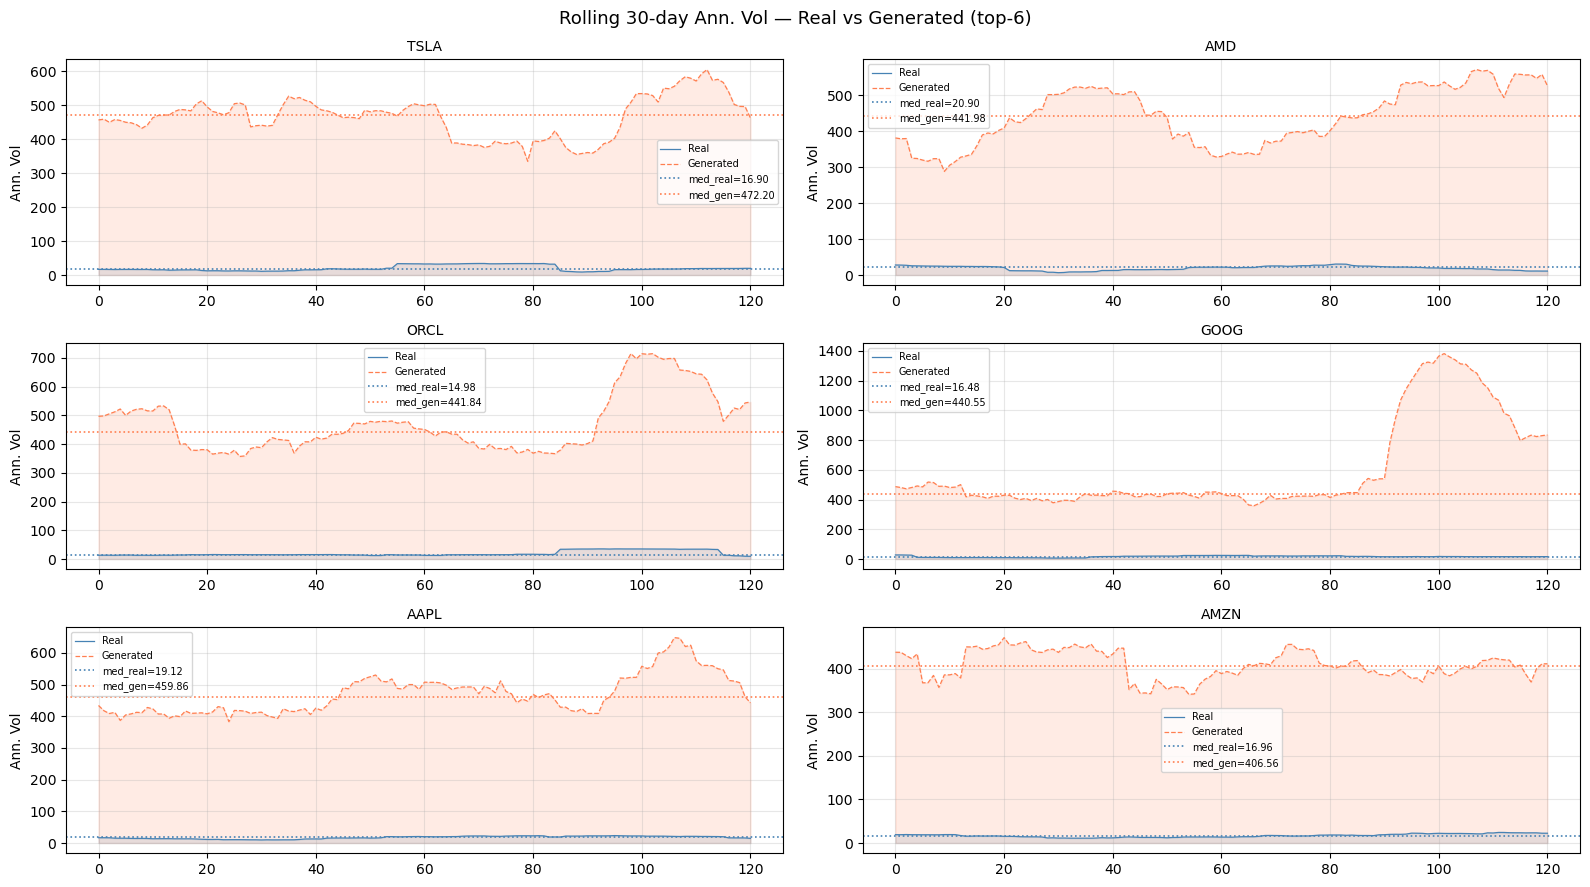

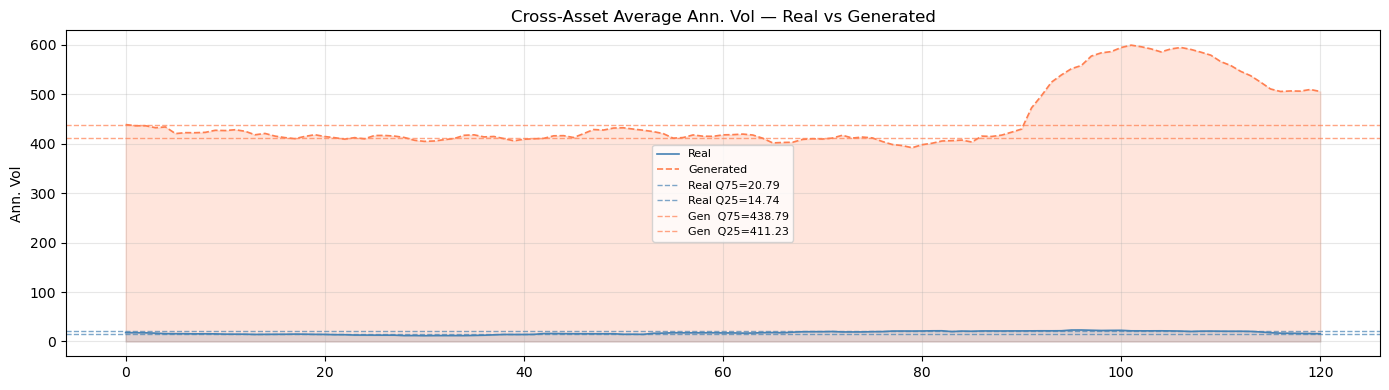

   vol_genai_vs_actual_per_asset.png
   vol_genai_vs_actual_avg.png


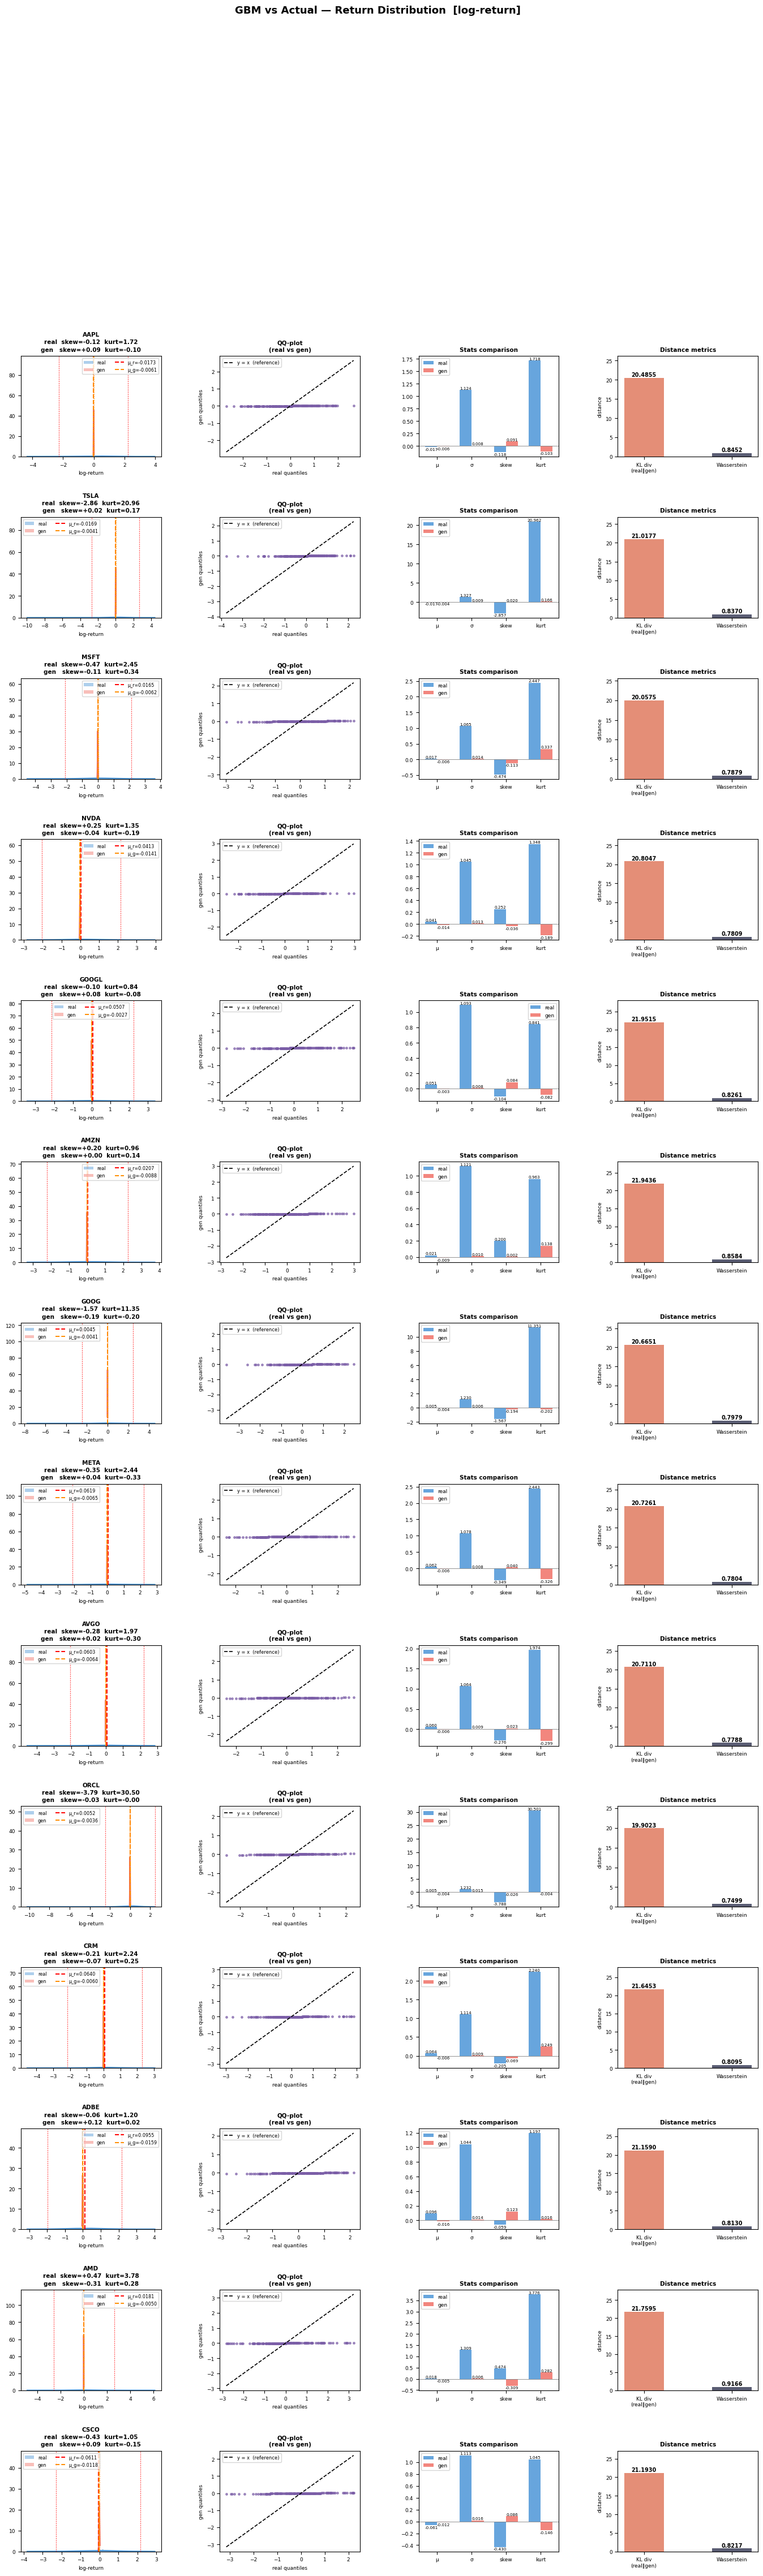

   dist_gbm_vs_actual.png


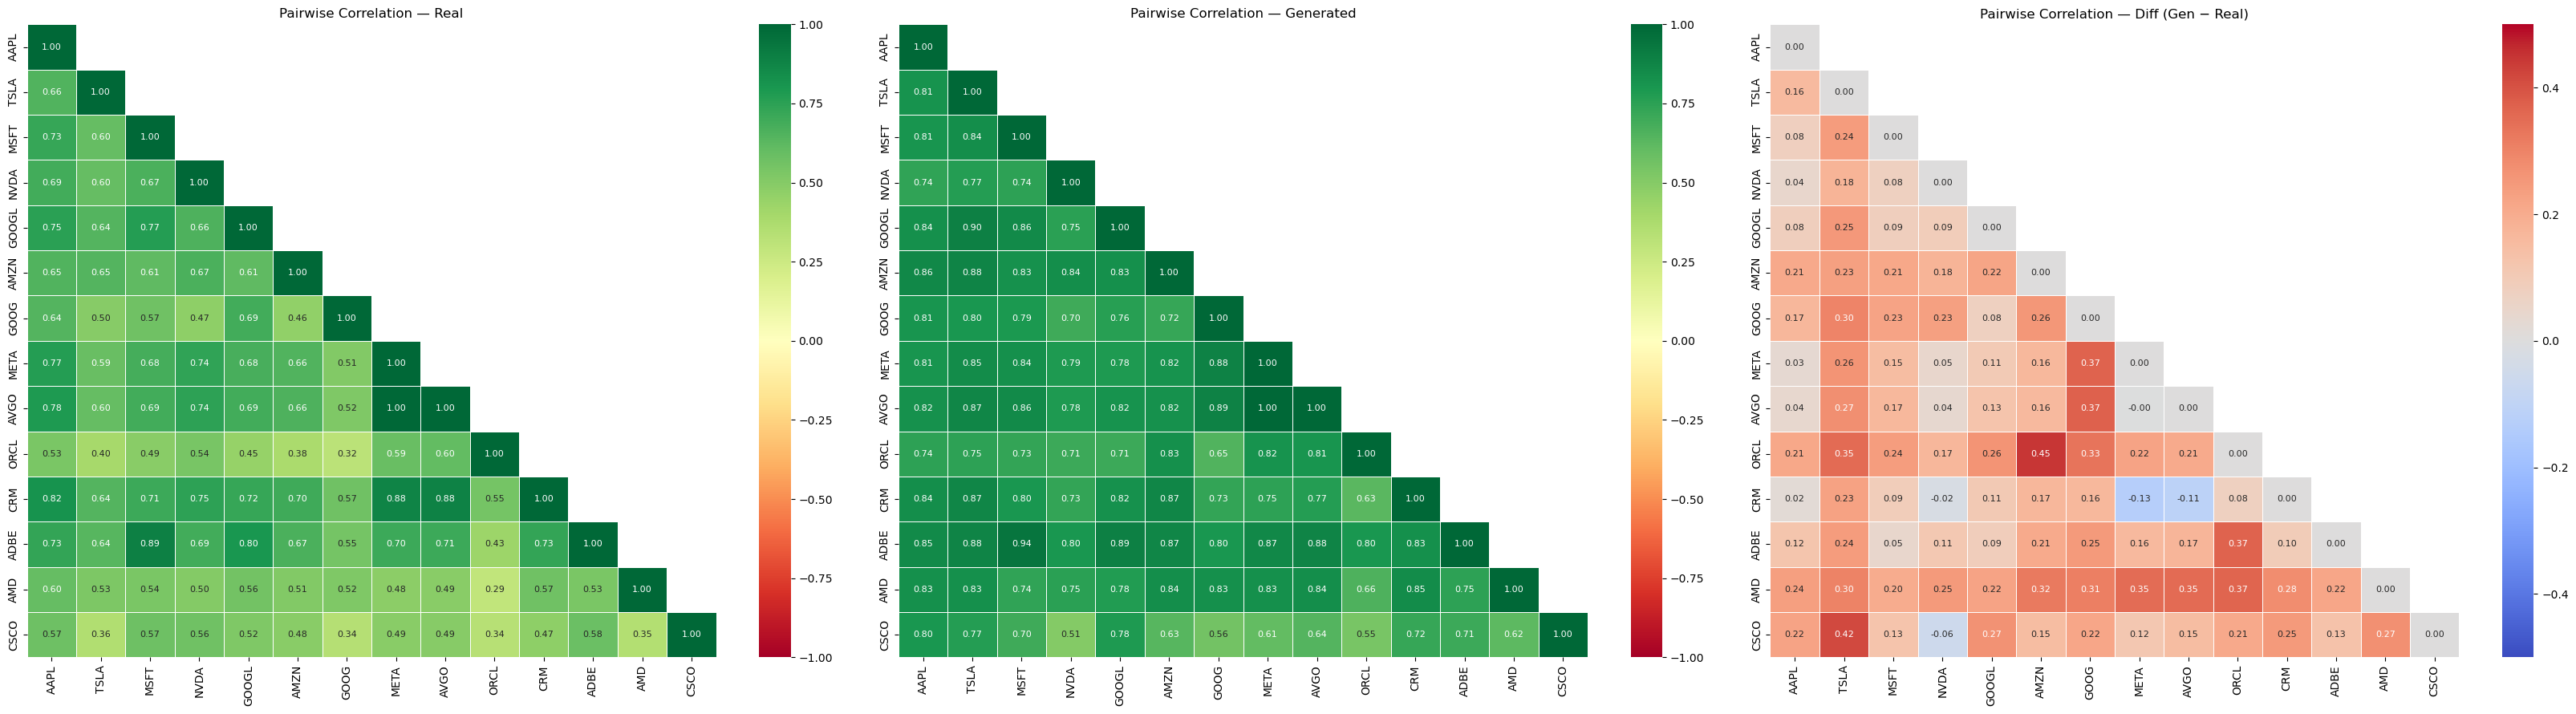


Pairs ที่ |r| > 0.85 ในอย่างน้อยหนึ่ง set:


,Asset A,Asset B,r_real,r_gen,delta
0,META,AVGO,0.998,0.996,-0.002
1,MSFT,ADBE,0.894,0.940,0.046
2,AVGO,CRM,0.884,0.772,-0.112
3,META,CRM,0.880,0.749,-0.130
4,GOOGL,ADBE,0.804,0.893,0.089
5,MSFT,GOOGL,0.772,0.857,0.085
6,AAPL,ADBE,0.729,0.853,0.124
7,AVGO,ADBE,0.708,0.882,0.174
8,META,ADBE,0.704,0.867,0.163
9,AMZN,CRM,0.700,0.870,0.171


   corr_gbm_vs_actual.png


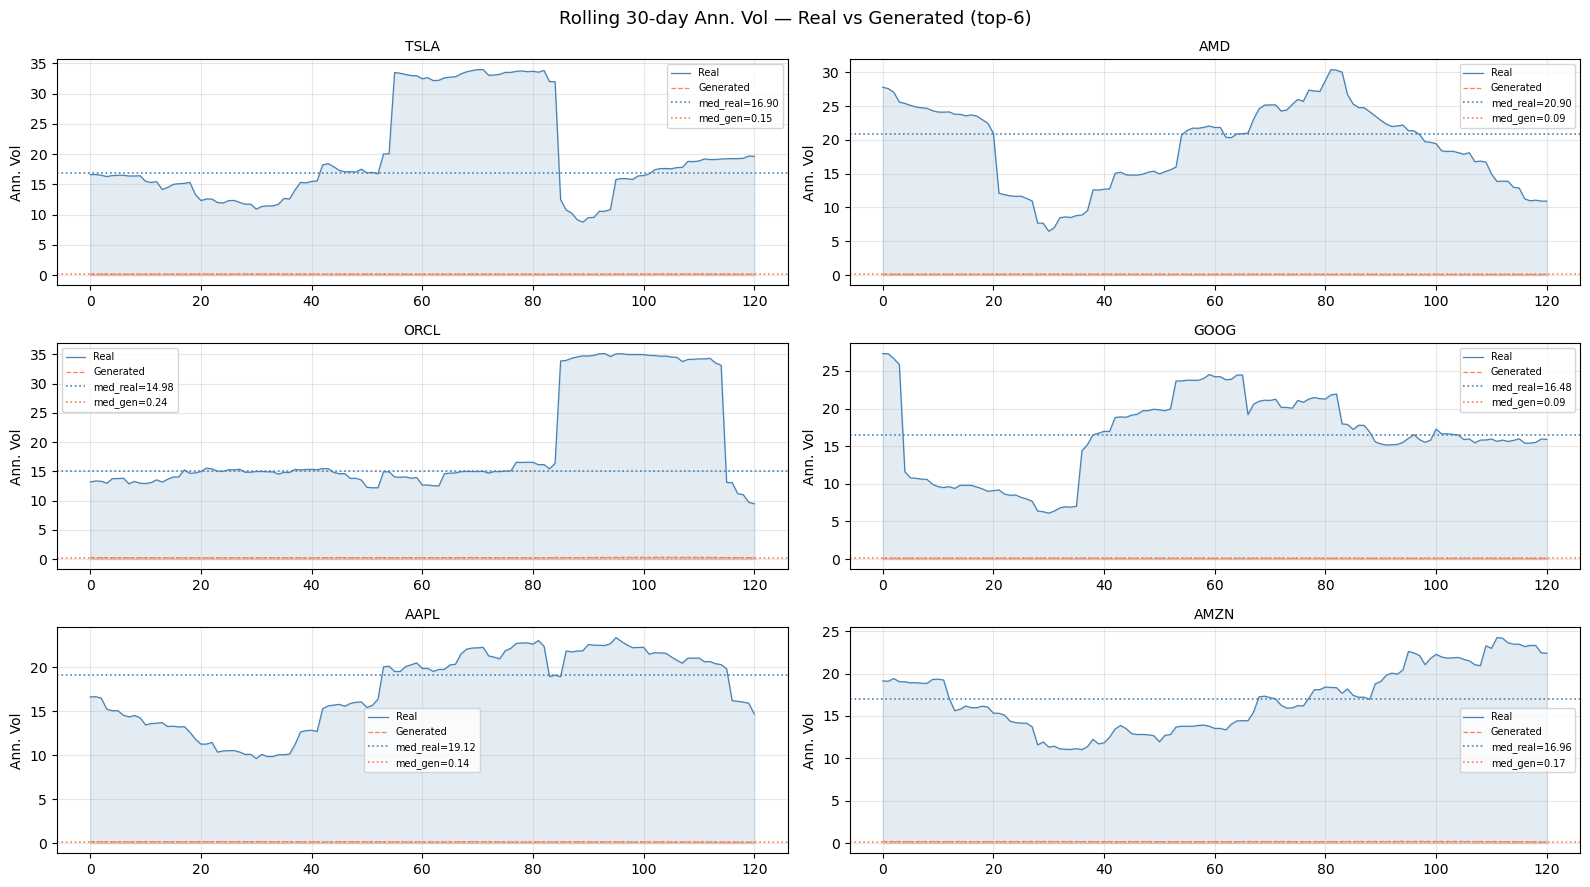

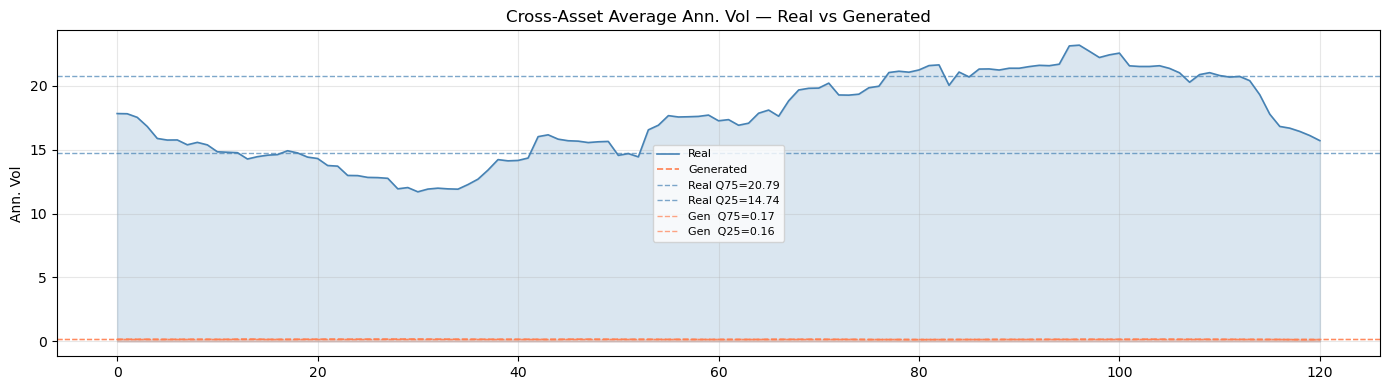

   vol_gbm_vs_actual_per_asset.png
   vol_gbm_vs_actual_avg.png


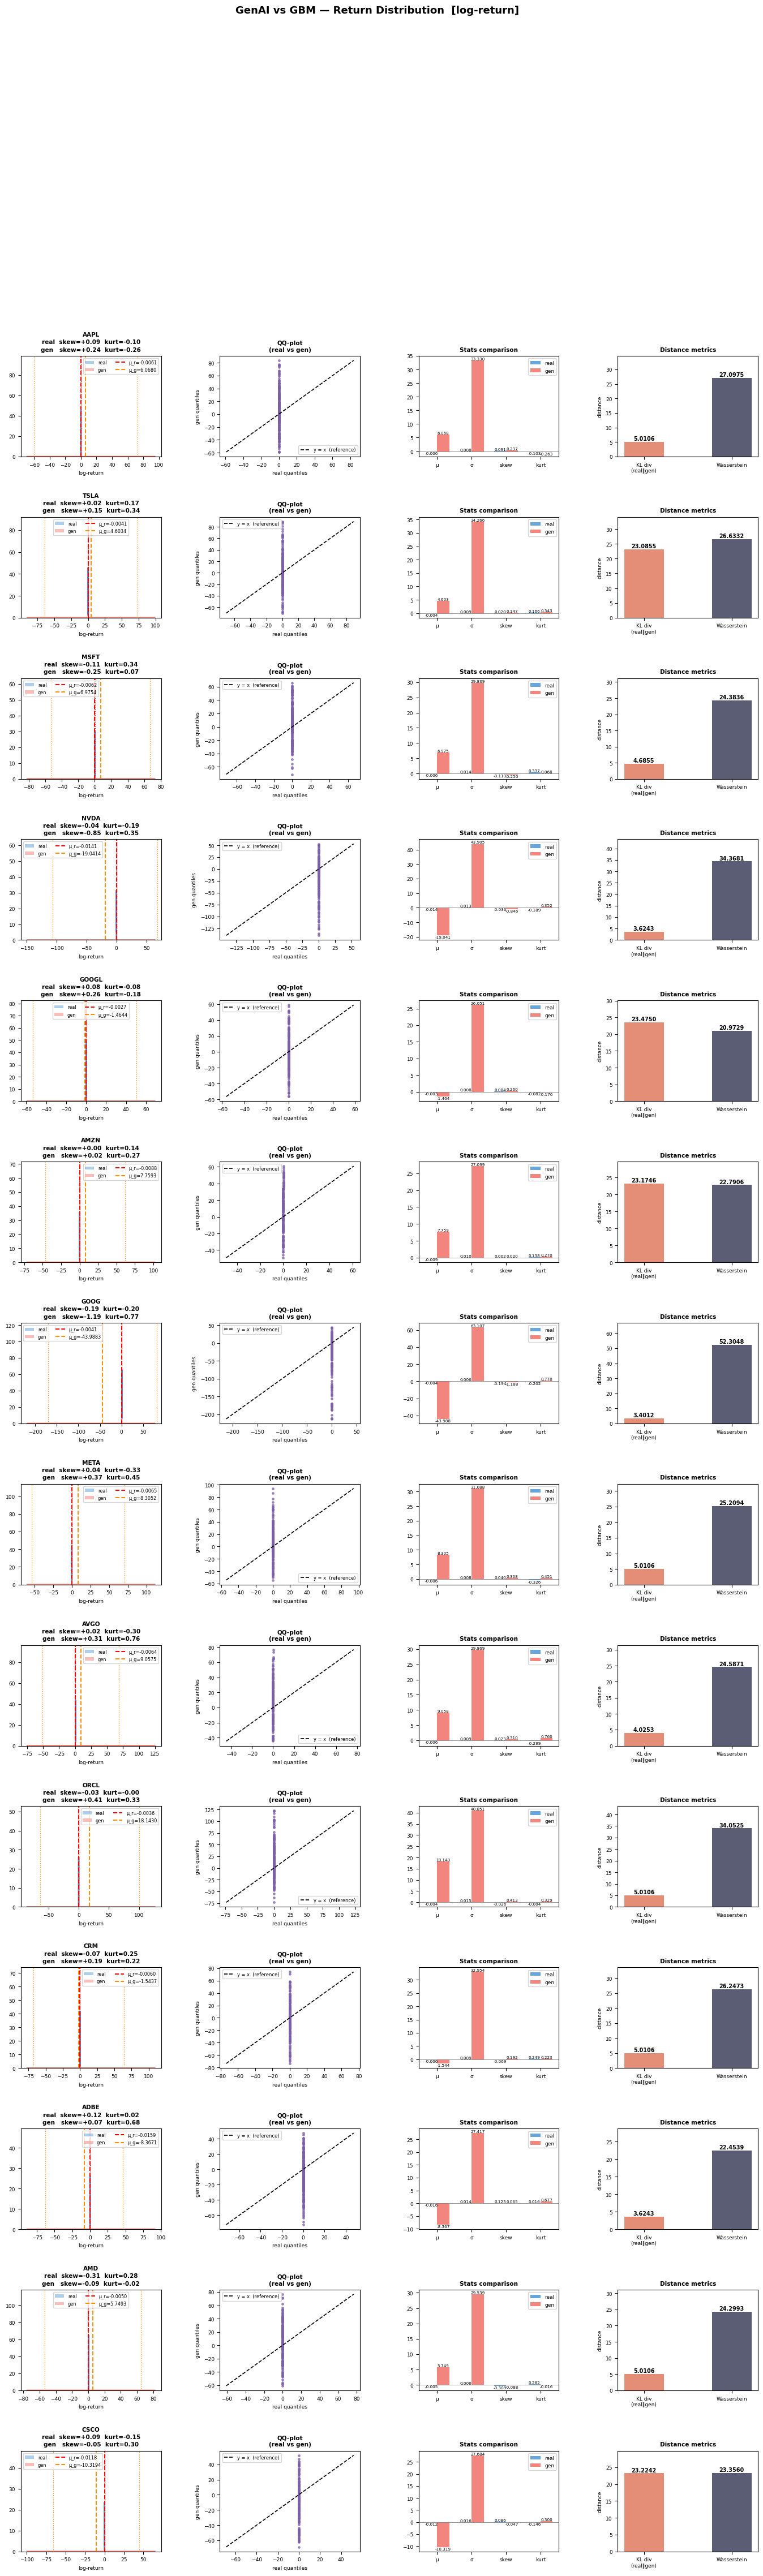

   dist_genai_vs_gbm.png


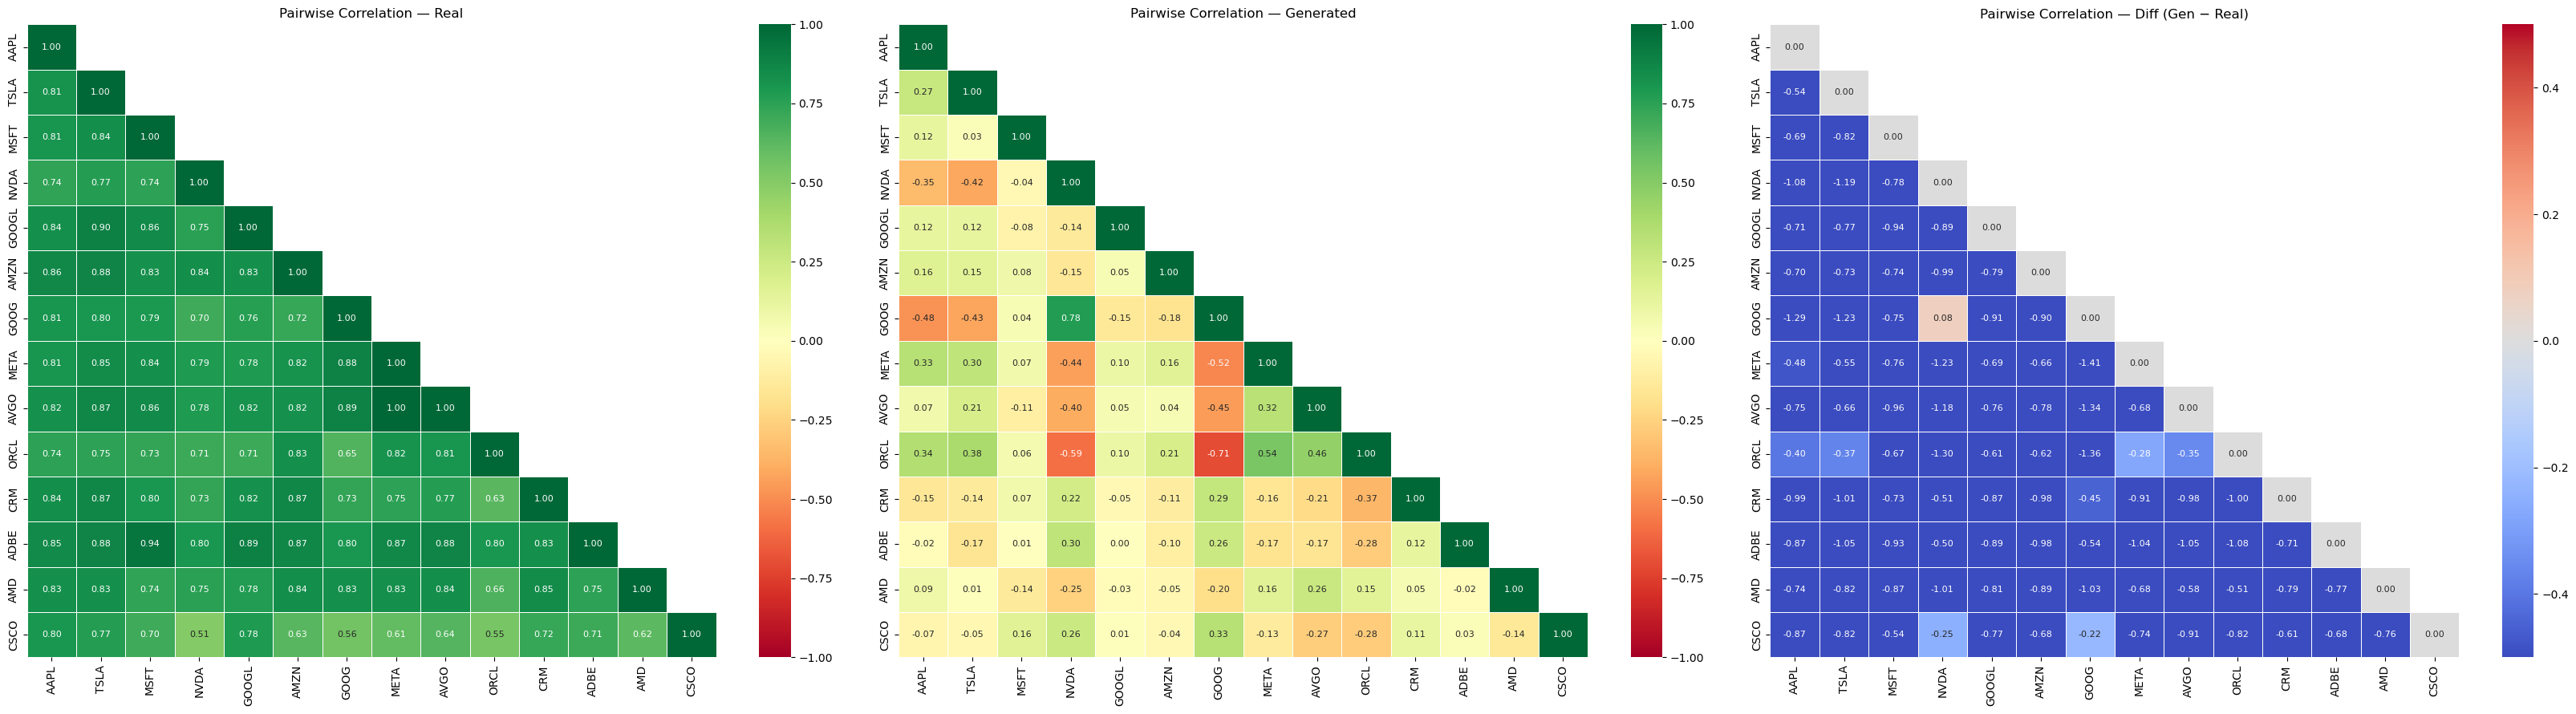


Pairs ที่ |r| > 0.85 ในอย่างน้อยหนึ่ง set:


,Asset A,Asset B,r_real,r_gen,delta
0,META,AVGO,0.996,0.321,-0.676
1,MSFT,ADBE,0.940,0.007,-0.932
2,TSLA,GOOGL,0.895,0.121,-0.774
3,GOOGL,ADBE,0.893,0.000,-0.892
4,GOOG,AVGO,0.888,-0.448,-1.336
5,GOOG,META,0.884,-0.522,-1.406
6,AVGO,ADBE,0.882,-0.167,-1.049
7,TSLA,ADBE,0.881,-0.171,-1.052
8,TSLA,AMZN,0.879,0.149,-0.731
9,AMZN,ADBE,0.874,-0.103,-0.977


   corr_genai_vs_gbm.png


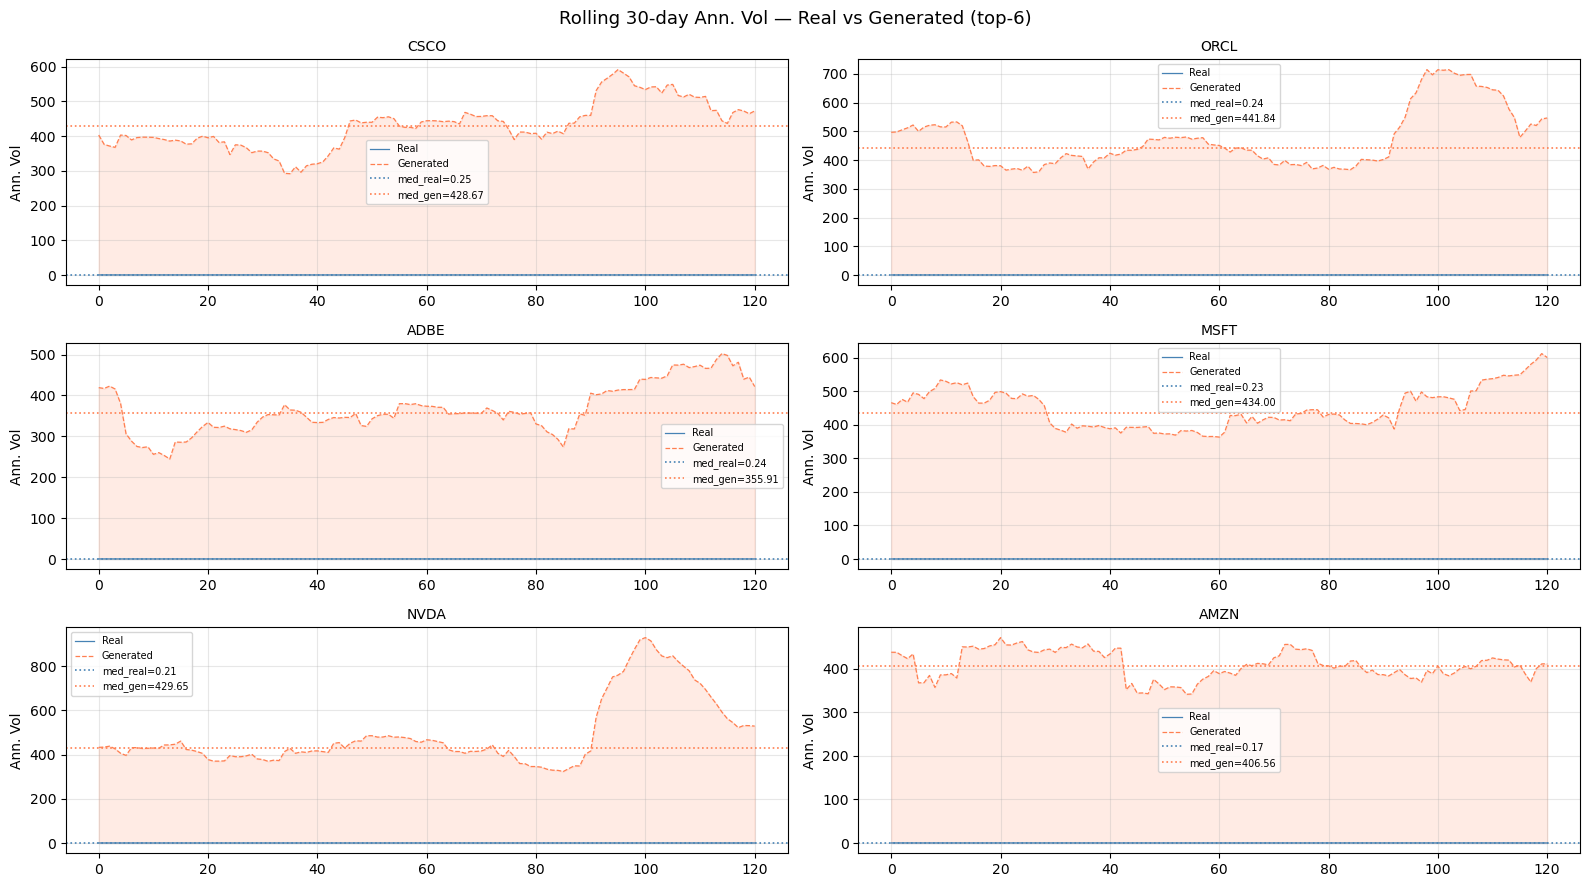

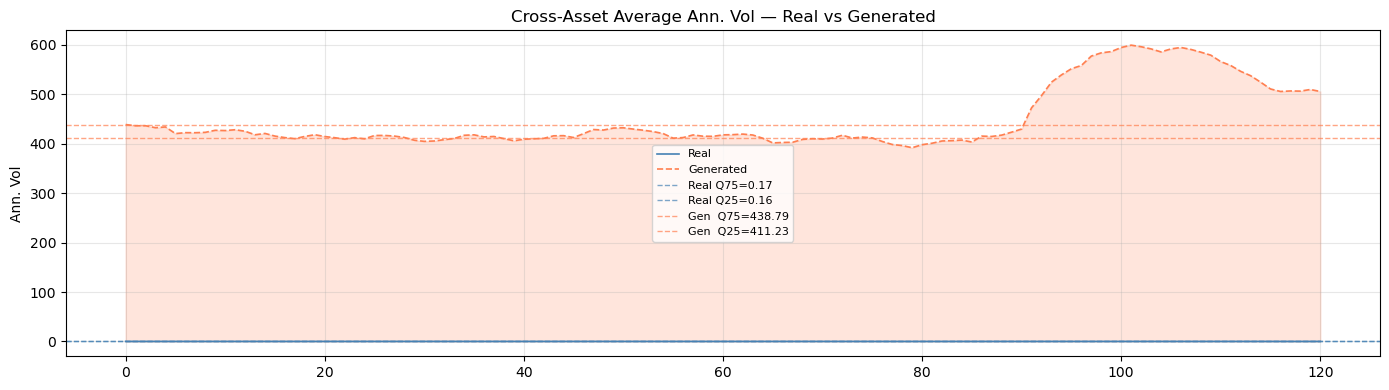

   vol_genai_vs_gbm_per_asset.png
   vol_genai_vs_gbm_avg.png
✅ R² plot saved → /home/narodom.y@FUSION.LAB/research/experiments/simulations/trial19_n10/plots/r2_genai_vs_gbm.png

✅ All done! Structure:
   /home/narodom.y@FUSION.LAB/research/experiments/simulations/trial19_n10/
   ├── sim_results.npz
   ├── sim_meta.json
   ├── plots/
   │   ├── dist_*.png  (3 comparisons)
   │   ├── corr_*.png  (3 comparisons)
   │   └── vol_*.png   (3 x 2 = 6 files)
   └── reports/
       ├── actual_log_returns.csv
       ├── genai_mean_path.csv
       ├── gbm_mean_path.csv
       ├── genai_paths_all_paths.csv   (long format)
       ├── gbm_paths_all_paths.csv     (long format)
       └── metrics_comparison.csv


In [ ]:
symbols = config.feature.symbols

# ── Directory structure ───────────────────────────────────────────────────────
plots_dir   = sim_dir / "plots"
reports_dir = sim_dir / "reports"
plots_dir.mkdir(parents=True, exist_ok=True)
reports_dir.mkdir(parents=True, exist_ok=True)

# ── Prep shapes [T, A] ────────────────────────────────────────────────────────
actual_TA = actual_cat.T                  # [150, A]
genai_TA  = gen_cat.mean(axis=0).T       # [150, A]  mean across n_paths
gbm_TA    = gbm_paths.mean(axis=0).T     # [150, A]  mean across n_paths

flat_dates_dt = pd.to_datetime(dates.reshape(-1))   # [150]  datetime index

# ── 1. Save .npz ─────────────────────────────────────────────────────────────
npz_path = sim_dir / "sim_results.npz"
np.savez_compressed(
    npz_path,
    generated    = generated,
    actual       = actual,
    dates        = dates,
    close_prices = close_prices,
    x_prev_mean  = x_prev_mean,
    x_prev_std   = x_prev_std,
    x_prev       = x_prev,
    # aggregated (cat) versions
    actual_cat   = actual_cat,     # [A, 150]
    gen_cat      = gen_cat,        # [n_paths, A, 150]
    gbm_paths    = gbm_paths,      # [n_paths, A, 150]
)

sim_meta = {
    "exp_name"       : EXP_NAME,
    "checkpoint"     : CKPT_FILE,
    "processed_name" : config.processed_name,
    "n_windows"      : int(generated.shape[0]),
    "n_paths"        : int(generated.shape[1]),
    "n_assets"       : int(generated.shape[2]),
    "window_size"    : int(generated.shape[3]),
    "channels"       : int(generated.shape[4]),
    "horizon"        : int(actual_TA.shape[0]),
    "symbols"        : symbols,
    "device"         : str(device),
}
with open(sim_dir / "sim_meta.json", "w") as f:
    json.dump(sim_meta, f, indent=4)

print(f"✅ npz saved  → {npz_path}")

# ── 2. CSV : mean paths (with date index) ─────────────────────────────────────
actual_df = pd.DataFrame(actual_TA, index=flat_dates_dt, columns=symbols)
genai_df  = pd.DataFrame(genai_TA,  index=flat_dates_dt, columns=symbols)
gbm_df    = pd.DataFrame(gbm_TA,    index=flat_dates_dt, columns=symbols)

actual_df.to_csv(reports_dir / "actual_log_returns.csv")
genai_df.to_csv(reports_dir  / "genai_mean_path.csv")
gbm_df.to_csv(reports_dir    / "gbm_mean_path.csv")
print(f"✅ mean path CSVs saved → {reports_dir}")

# ── 3. CSV : per-path (long format) ───────────────────────────────────────────
# gen_cat  : [n_paths, A, 150]
# gbm_paths: [n_paths, A, 150]
for name, arr in [("genai_paths", gen_cat), ("gbm_paths", gbm_paths)]:
    n_p, n_a, n_t = arr.shape
    records = []
    for p in range(n_p):
        df_p = pd.DataFrame(
            arr[p].T,                   # [150, A]
            index=flat_dates_dt,
            columns=symbols,
        )
        df_p.index.name = "date"
        df_p["path"] = p
        records.append(df_p.reset_index())
    pd.concat(records, ignore_index=True).to_csv(
        reports_dir / f"{name}_all_paths.csv", index=False
    )
print(f"✅ per-path CSVs saved → {reports_dir}")

# ── 4. Metrics table ──────────────────────────────────────────────────────────
def compute_metrics_df(ref_TA, pred_TA, pred_label, ref_label="Actual"):
    """ref_TA, pred_TA : [T, A]"""
    rows = []
    for i, sym in enumerate(symbols):
        r = ref_TA[:, i].astype(float)
        g = pred_TA[:, i].astype(float)
        r, g = r[np.isfinite(r)], g[np.isfinite(g)]
        min_len = min(len(r), len(g))
        mse = float(np.mean((r[:min_len] - g[:min_len]) ** 2))
        mae = float(np.mean(np.abs(r[:min_len] - g[:min_len])))
        kl  = _kl_divergence(r, g)
        wd  = float(wasserstein_distance(r, g))
        r2 = float(r2_score(r[:min_len], g[:min_len]))
        rows.append({
            "asset"                   : sym,
            f"MSE_{pred_label}"       : round(mse, 8),
            f"MAE_{pred_label}"       : round(mae, 8),
            f"KL_{pred_label}"        : round(kl,  6),
            f"Wasserstein_{pred_label}": round(wd,  6),
            f"R2_{pred_label}": round(r2, 6),
        })
    return pd.DataFrame(rows).set_index("asset")

metrics_genai = compute_metrics_df(actual_TA, genai_TA, "GenAI")
metrics_gbm   = compute_metrics_df(actual_TA, gbm_TA,   "GBM")
metrics_all   = pd.concat([metrics_genai, metrics_gbm], axis=1)
metrics_all.to_csv(reports_dir / "metrics_comparison.csv")
print(f"✅ metrics saved → {reports_dir / 'metrics_comparison.csv'}")
print(metrics_all.to_string())

# ── 5. Plots ──────────────────────────────────────────────────────────────────
def _save(fig, name):
    fig.savefig(plots_dir / name, bbox_inches="tight", dpi=120)
    plt.close(fig)
    print(f"   {name}")

print(f"\nSaving plots → {plots_dir}")

# GenAI vs Actual
fig, _ = plot_compare_dist(actual_TA, genai_TA, symbols,
                           title="GenAI vs Actual — Return Distribution")
_save(fig, "dist_genai_vs_actual.png")

fig, _, _ = plot_compare_correlation(actual_TA, genai_TA, symbols)
_save(fig, "corr_genai_vs_actual.png")

fig1, fig2 = plot_compare_rolling_vol(actual_TA, genai_TA, symbols)
_save(fig1, "vol_genai_vs_actual_per_asset.png")
_save(fig2, "vol_genai_vs_actual_avg.png")

# GBM vs Actual
fig, _ = plot_compare_dist(actual_TA, gbm_TA, symbols,
                           title="GBM vs Actual — Return Distribution")
_save(fig, "dist_gbm_vs_actual.png")

fig, _, _ = plot_compare_correlation(actual_TA, gbm_TA, symbols)
_save(fig, "corr_gbm_vs_actual.png")

fig1, fig2 = plot_compare_rolling_vol(actual_TA, gbm_TA, symbols)
_save(fig1, "vol_gbm_vs_actual_per_asset.png")
_save(fig2, "vol_gbm_vs_actual_avg.png")

# GenAI vs GBM
fig, _ = plot_compare_dist(gbm_TA, genai_TA, symbols,
                           title="GenAI vs GBM — Return Distribution")
_save(fig, "dist_genai_vs_gbm.png")

fig, _, _ = plot_compare_correlation(gbm_TA, genai_TA, symbols)
_save(fig, "corr_genai_vs_gbm.png")

fig1, fig2 = plot_compare_rolling_vol(gbm_TA, genai_TA, symbols)
_save(fig1, "vol_genai_vs_gbm_per_asset.png")
_save(fig2, "vol_genai_vs_gbm_avg.png")

# ── plot R² bar chart หลัง compute metrics ───────────────────
fig, ax = plt.subplots(figsize=(14, 5))
x      = np.arange(len(symbols))
width  = 0.35

ax.bar(x - width/2, metrics_genai["R2_GenAI"], width,
       color="#4C96D7", alpha=0.85, label="GenAI")
ax.bar(x + width/2, metrics_gbm["R2_GBM"],   width,
       color="#F07167", alpha=0.85, label="GBM")

ax.axhline(0, color="black", lw=0.8, linestyle="--")
ax.axhline(1, color="grey",  lw=0.8, linestyle=":")
ax.set_xticks(x)
ax.set_xticklabels(symbols, rotation=45, ha="right", fontsize=9)
ax.set_ylabel("R² Score")
ax.set_title("R² Score per Asset — GenAI vs GBM (vs Actual)")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()

fig.savefig(plots_dir / "r2_genai_vs_gbm.png", bbox_inches="tight", dpi=120)
plt.close(fig)
print(f"✅ R² plot saved → {plots_dir / 'r2_genai_vs_gbm.png'}")

print(f"\n✅ All done! Structure:")
print(f"   {sim_dir}/")
print(f"   ├── sim_results.npz")
print(f"   ├── sim_meta.json")
print(f"   ├── plots/")
print(f"   │   ├── dist_*.png  (3 comparisons)")
print(f"   │   ├── corr_*.png  (3 comparisons)")
print(f"   │   └── vol_*.png   (3 x 2 = 6 files)")
print(f"   └── reports/")
print(f"       ├── actual_log_returns.csv")
print(f"       ├── genai_mean_path.csv")
print(f"       ├── gbm_mean_path.csv")
print(f"       ├── genai_paths_all_paths.csv   (long format)")
print(f"       ├── gbm_paths_all_paths.csv     (long format)")
print(f"       └── metrics_comparison.csv")

In [ ]:
import shutil

shutil.copy(
    exp_dir / "config.json",
    sim_dir / "config.json",
)
print(f"✅ config.json copied → {sim_dir / 'config.json'}")

✅ config.json copied → /home/narodom.y@FUSION.LAB/research/experiments/simulations/trial19_n10/config.json
